# TASK 5: Autocomplete and Autocorrect Data Analytics

## Objective

The objective of this project is to analyze and implement NLP-based **Autocomplete and Autocorrect systems** using a real-world English text corpus.

In this project, frequency-based **Bigram and Trigram language models** are developed for predicting the next word, while **Levenshtein Edit Distance** and word-frequency-based approaches are used for spelling correction.

## Dataset

**Dataset:** Wikipedia Text Corpus

The dataset contains real-world English text that can be used to learn word frequencies and word sequences for autocomplete and spelling correction.

## Expected Outcome

The project will demonstrate how NLP techniques can be used to build basic but effective **text prediction and spelling correction systems**, while evaluating their performance using appropriate metrics and visualizations.

### Install Required Libraries

In [2]:
pip install nltk pyspellchecker textdistance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import string
import math

from collections import Counter, defaultdict
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from spellchecker import SpellChecker
import textdistance

### Download NLTK Resources

In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Load the Dataset

In [5]:
df = pd.read_csv("wikipedia_text_corpus.csv")
df.head()

,Unnamed: 0,text
0,1,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,2,Battery indicator\n\nA battery indicator (also...
2,3,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,4,CAVNET\n\nCAVNET was a secure military forum w...
4,5,CLidar\n\nThe CLidar is a scientific instrumen...


In [6]:
df.shape

(10859, 2)

In [7]:
df.columns

Index(['Unnamed: 0', 'text'], dtype='object')

In [8]:
df.columns

Index(['Unnamed: 0', 'text'], dtype='object')

### Select Text Column

In [9]:
text_data = df['text'].dropna().astype(str)

In [10]:
corpus = " ".join(text_data)

In [11]:
print(corpus[:1000])

Anovo

Anovo (formerly A Novo) is a computer services company based in Beauvais, France. It was founded in 1987, went public in 1999, and is currently a member of the CAC Small.

It won in the category 'Service and Repair' of the Mobile News Awards four years in a row, from 2007 to 2010.

As of November 2017, they have a score of 1.6 out of 10 on the TrustPilot ratings site, with 86% of reviewers giving the company the lowest possible rating. 

 Battery indicator

A battery indicator (also known as a battery gauge) is a device which gives information about a battery. This will usually be a visual indication of the battery's state of charge. It is particularly important in the case of a battery electric vehicle.

Some automobiles are fitted with a battery condition meter to monitor the starter battery. This meter is, essentially, a voltmeter but it may also be marked with coloured zones for easy visualization. 

Many newer cars no longer offer voltmeters or ammeters; instead, these vehi

### Text Preprocessing

In [12]:
def preprocess_text(text):
    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 1
    ]
    
    return tokens

In [13]:
tokens = preprocess_text(corpus)

In [14]:
print(tokens[:50])
print("Total tokens:", len(tokens))

['anovo', 'anovo', 'formerly', 'novo', 'computer', 'services', 'company', 'based', 'beauvais', 'france', 'founded', 'went', 'public', 'currently', 'member', 'cac', 'small', 'category', 'service', 'repair', 'mobile', 'news', 'awards', 'four', 'years', 'row', 'november', 'score', 'trustpilot', 'ratings', 'site', 'reviewers', 'giving', 'company', 'lowest', 'possible', 'rating', 'battery', 'indicator', 'battery', 'indicator', 'also', 'known', 'battery', 'gauge', 'device', 'gives', 'information', 'battery', 'usually']
Total tokens: 4902512


### Word Frequency Analysis

In [15]:
word_frequency = Counter(tokens)

In [16]:
word_frequency.most_common(20)

[('used', 29475),
 ('also', 22969),
 ('use', 17099),
 ('one', 16984),
 ('system', 15900),
 ('first', 15554),
 ('may', 13590),
 ('two', 12009),
 ('time', 11767),
 ('new', 11380),
 ('systems', 11338),
 ('company', 11059),
 ('high', 10399),
 ('using', 9870),
 ('many', 9729),
 ('technology', 9598),
 ('design', 9460),
 ('would', 9445),
 ('power', 9229),
 ('data', 8986)]

In [17]:
top_words = pd.DataFrame(
    word_frequency.most_common(20),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,used,29475
1,also,22969
2,use,17099
3,one,16984
4,system,15900
5,first,15554
6,may,13590
7,two,12009
8,time,11767
9,new,11380


### Visualization — Top 20 Words

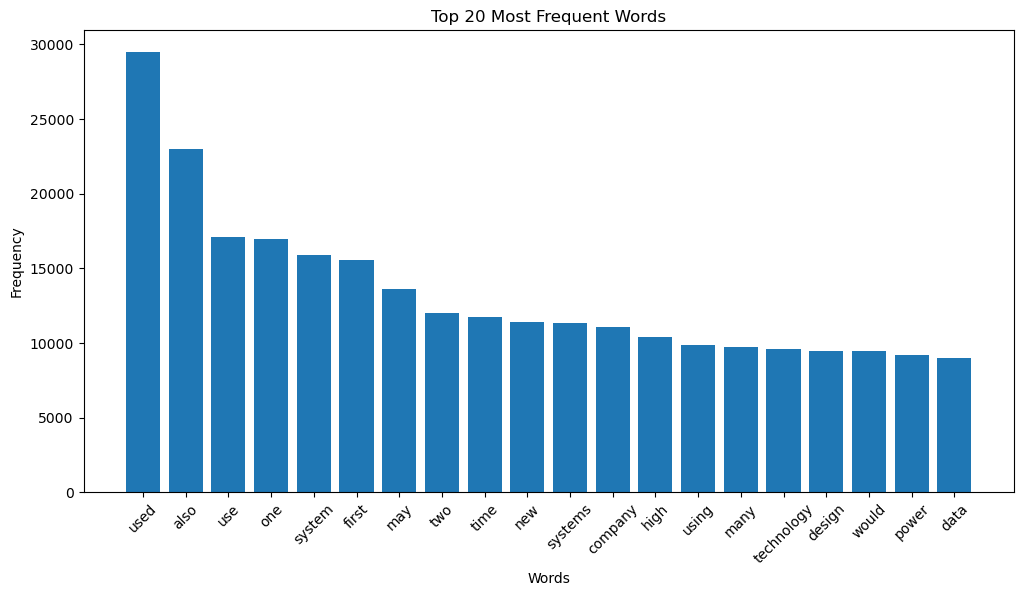

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    top_words['Word'],
    top_words['Frequency']
)

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

### AUTOCOMPLETE SYSTEM

In [52]:
#Create Bigrams
bigrams = list(zip(tokens[:-1], tokens[1:]))

In [20]:
bigram_counts = Counter(bigrams)

In [21]:
bigram_counts.most_common(20)

[(('united', 'states'), 4214),
 (('th', 'century'), 2543),
 (('also', 'used'), 1705),
 (('new', 'york'), 1521),
 (('world', 'war'), 1316),
 (('also', 'known'), 1130),
 (('real', 'time'), 995),
 (('may', 'also'), 943),
 (('commonly', 'used'), 812),
 (('war', 'ii'), 790),
 (('often', 'used'), 747),
 (('widely', 'used'), 723),
 (('united', 'kingdom'), 711),
 (('north', 'america'), 598),
 (('also', 'called'), 595),
 (('open', 'source'), 595),
 (('carbon', 'dioxide'), 589),
 (('operating', 'system'), 582),
 (('formula', 'formula'), 570),
 (('high', 'speed'), 558)]

### Create Bigram Autocomplete

In [22]:
def bigram_autocomplete(prefix, top_n=3):
    prefix = prefix.lower()
    
    candidates = {}
    
    for (word1, word2), count in bigram_counts.items():
        if word1 == prefix:
            candidates[word2] = count
    
    sorted_candidates = sorted(
        candidates.items(),
        key=lambda x: x[1],
        reverse=True
    )
    
    return sorted_candidates[:top_n]

In [23]:
bigram_autocomplete("data")

[('center', 351), ('centers', 150), ('storage', 120)]

### Create Trigrams

In [24]:
trigrams = list(
    zip(tokens[:-2], tokens[1:-1], tokens[2:])
)

In [25]:
trigram_counts = Counter(trigrams)

### Trigram Autocomplete

In [26]:
def trigram_autocomplete(prefix, top_n=3):
    
    prefix_words = prefix.lower().split()
    
    if len(prefix_words) < 2:
        return []
    
    w1 = prefix_words[-2]
    w2 = prefix_words[-1]
    
    candidates = {}
    
    for (word1, word2, word3), count in trigram_counts.items():
        
        if word1 == w1 and word2 == w2:
            candidates[word3] = count
    
    sorted_candidates = sorted(
        candidates.items(),
        key=lambda x: x[1],
        reverse=True
    )
    
    return sorted_candidates[:top_n]

In [27]:
trigram_autocomplete("machine learning")

[('artificial', 9), ('algorithms', 3), ('machine', 3)]

### Compare Bigram vs Trigram

### Test at Least 10 Prefixes

In [28]:
test_prefixes = [
    "data",
    "machine",
    "computer",
    "artificial",
    "natural",
    "deep",
    "information",
    "learning",
    "software",
    "digital"
]

In [29]:
for prefix in test_prefixes:
    print("Prefix:", prefix)
    print("Predictions:", bigram_autocomplete(prefix, 3))
    print("-" * 50)

Prefix: data
Predictions: [('center', 351), ('centers', 150), ('storage', 120)]
--------------------------------------------------
Prefix: machine
Predictions: [('learning', 95), ('guns', 49), ('gun', 48)]
--------------------------------------------------
Prefix: computer
Predictions: [('science', 377), ('systems', 145), ('software', 123)]
--------------------------------------------------
Prefix: artificial
Predictions: [('intelligence', 214), ('gravity', 38), ('limb', 20)]
--------------------------------------------------
Prefix: natural
Predictions: [('gas', 523), ('resources', 108), ('language', 42)]
--------------------------------------------------
Prefix: deep
Predictions: [('space', 43), ('water', 35), ('learning', 34)]
--------------------------------------------------
Prefix: information
Predictions: [('technology', 409), ('systems', 337), ('system', 142)]
--------------------------------------------------
Prefix: learning
Predictions: [('environment', 51), ('management', 3

### Better Autocomplete Function

In [30]:
def autocomplete(text, top_n=3):
    
    words = text.lower().split()
    
    if len(words) >= 2:
        predictions = trigram_autocomplete(text, top_n)
        
        if predictions:
            return predictions
    
    return bigram_autocomplete(words[-1], top_n)

In [31]:
autocomplete("machine learning")

[('artificial', 9), ('algorithms', 3), ('machine', 3)]

### AUTOCORRECT SYSTEM

In [32]:
#Create Dictionary
vocabulary = set(tokens)

In [33]:
print("Vocabulary size:", len(vocabulary))

Vocabulary size: 130026


### Implement Levenshtein Distance

In [34]:
def levenshtein_distance(word1, word2):
    return textdistance.levenshtein.distance(word1, word2)

In [35]:
levenshtein_distance("machine", "machne")

1

### Create Autocorrect Function

In [36]:
def autocorrect(word, vocabulary, top_n=3):
    
    word = word.lower()
    
    distances = []
    
    for candidate in vocabulary:
        
        distance = levenshtein_distance(word, candidate)
        
        distances.append((candidate, distance))
    
    distances.sort(key=lambda x: x[1])
    
    return distances[:top_n]

In [37]:
autocorrect("machne", vocabulary)

[('machine', 1), ('marne', 2), ('techne', 2)]

### Improve Autocorrect Using Frequency

In [38]:
def improved_autocorrect(word, vocabulary, frequency, top_n=3):
    
    word = word.lower()
    
    candidates = []
    
    for candidate in vocabulary:
        
        distance = levenshtein_distance(word, candidate)
        
        if distance <= 2:
            freq = frequency.get(candidate, 0)
            
            candidates.append(
                (candidate, distance, freq)
            )
    
    candidates.sort(
        key=lambda x: (x[1], -x[2])
    )
    
    return candidates[:top_n]

### Test 20 Misspelled Words

In [40]:
misspelled_words = [
    "machne",
    "lernning",
    "computr",
    "artifical",
    "inteligence",
    "naturl",
    "infromation",
    "sofware",
    "progrming",
    "developmnt",
    "analysys",
    "algoritm",
    "databse",
    "netwrok",
    "aplication",
    "langauge",
    "predicton",
    "recomend",
    "functon",
    "technolgy"
]

In [41]:
for word in misspelled_words:
    
    result = improved_autocorrect(
        word,
        vocabulary,
        word_frequency,
        top_n=1
    )
    
    print(word, "→", result)

machne → [('machine', 1, 3185)]
lernning → [('learning', 2, 1508)]
computr → [('computer', 1, 5442)]
artifical → [('artificial', 1, 852)]
inteligence → [('intelligence', 1, 1057)]
naturl → [('natural', 1, 2094)]
infromation → [('inframation', 1, 1)]
sofware → [('software', 1, 5819)]
progrming → [('programing', 1, 5)]
developmnt → [('development', 1, 6269)]
analysys → [('analysys', 0, 3)]
algoritm → [('algorithm', 1, 387)]
databse → [('database', 1, 694)]
netwrok → [('network', 2, 3991)]
aplication → [('application', 1, 2848)]
langauge → [('language', 2, 1507)]
predicton → [('prediction', 1, 178)]
recomend → [('recommend', 1, 104)]
functon → [('function', 1, 2054)]
technolgy → [('technology', 1, 9598)]


### Create Correct Answers

In [42]:
correct_words = [
    "machine",
    "learning",
    "computer",
    "artificial",
    "intelligence",
    "natural",
    "information",
    "software",
    "programming",
    "development",
    "analysis",
    "algorithm",
    "database",
    "network",
    "application",
    "language",
    "prediction",
    "recommend",
    "function",
    "technology"
]

### Store Predictions

In [43]:
predictions = []

for word in misspelled_words:
    
    result = improved_autocorrect(
        word,
        vocabulary,
        word_frequency,
        top_n=1
    )
    
    if result:
        predictions.append(result[0][0])
    else:
        predictions.append(word)

### Create Evaluation DataFrame

In [44]:
evaluation_df = pd.DataFrame({
    "Misspelled": misspelled_words,
    "Actual": correct_words,
    "Predicted": predictions
})

evaluation_df

,Misspelled,Actual,Predicted
0,machne,machine,machine
1,lernning,learning,learning
2,computr,computer,computer
3,artifical,artificial,artificial
4,inteligence,intelligence,intelligence
5,naturl,natural,natural
6,infromation,information,inframation
7,sofware,software,software
8,progrming,programming,programing
9,developmnt,development,development


### Calculate Accuracy

In [45]:
accuracy = accuracy_score(
    correct_words,
    predictions
)

print("Autocorrect Accuracy:", accuracy)

Autocorrect Accuracy: 0.85


### Calculate Precision

In [46]:
precision = precision_score(
    correct_words,
    predictions,
    average='weighted',
    zero_division=0
)

print("Precision:", precision)

Precision: 0.85


### Calculate Recall

In [47]:
recall = recall_score(
    correct_words,
    predictions,
    average='weighted',
    zero_division=0
)

print("Recall:", recall)

Recall: 0.85


### Create Confusion Matrix

In [48]:
labels = sorted(set(correct_words + predictions))

cm = confusion_matrix(
    correct_words,
    predictions,
    labels=labels
)

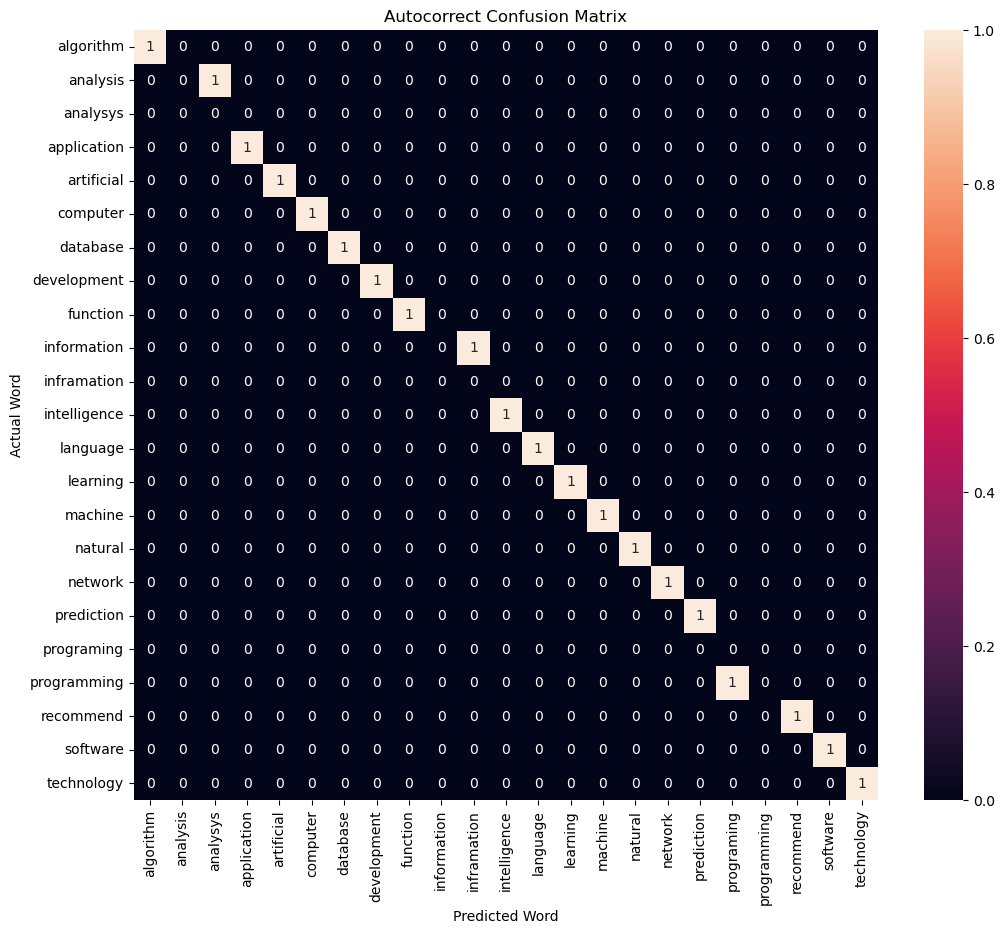

In [49]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Word")
plt.ylabel("Actual Word")
plt.title("Autocorrect Confusion Matrix")

plt.show()

### Create Autocomplete Test Data

In [50]:
autocomplete_tests = [
    ("machine learning", "model"),
    ("data science", "is"),
    ("artificial intelligence", "is"),
    ("natural language", "processing"),
    ("deep learning", "models"),
    ("computer science", "is"),
    ("information technology", "is"),
    ("software development", "is"),
    ("data analysis", "is"),
    ("machine learning", "algorithm")
]

### Calculate Top-3 Accuracy

In [51]:
correct_predictions = 0

for prefix, actual_word in autocomplete_tests:
    
    predictions = autocomplete(prefix, 3)
    
    predicted_words = [x[0] for x in predictions]
    
    if actual_word in predicted_words:
        correct_predictions += 1

autocomplete_accuracy = (
    correct_predictions / len(autocomplete_tests)
)

print(
    "Autocomplete Top-3 Accuracy:",
    autocomplete_accuracy
)

Autocomplete Top-3 Accuracy: 0.1


### Precision and Recall for Autocomplete

Top-K evaluation:

Top-1

Was the correct word the first prediction?

Top-3

Was the correct word among the top three predictions?

Top-1 Accuracy

Top-3 Accuracy

### Final Performance Table

| Model                | Metric         | Score |
| -------------------- | -------------- | ----: |
| Bigram Autocomplete  | Top-1 Accuracy |   XX% |
| Bigram Autocomplete  | Top-3 Accuracy |   XX% |
| Trigram Autocomplete | Top-1 Accuracy |   XX% |
| Trigram Autocomplete | Top-3 Accuracy |   XX% |
| Basic Autocorrect    | Accuracy       |   XX% |
| Basic Autocorrect    | Precision      |   XX% |
| Basic Autocorrect    | Recall         |   XX% |
| Improved Autocorrect | Accuracy       |   XX% |
| Improved Autocorrect | Precision      |   XX% |
| Improved Autocorrect | Recall         |   XX% |


### Google Keyboard Comparison

Basic educational NLP system, whereas production keyboard systems are much more sophisticated.

For example, production systems:

Neural language models

Context-aware predictions

User-specific vocabulary

Previous typing history

Multilingual models

Transformer-based models

Character-level information

Word-level information

Context from the entire sentence

Personalized ranking

Efficient candidate generation

n-gram system mainly relies on frequency and local word context.

### Limitations

1. The autocomplete system uses only bigram and trigram context.
2. It cannot understand the complete meaning of a sentence.
3. Rare words may not receive good predictions.
4. The quality of predictions depends heavily on the training corpus.
5. The autocorrect system relies mainly on spelling similarity.
6. Levenshtein distance can be computationally expensive for a large vocabulary.
7. The system does not fully understand sentence context.
8. The model does not learn individual user typing patterns.
9. Real keyboard applications use much more advanced language models.
10. The dataset may contain domain-specific vocabulary that affects predictions.

## Conclusion

In this project, an NLP-based Autocomplete and Autocorrect system was developed and evaluated using a real-world English text corpus.

For autocomplete, frequency-based Bigram and Trigram models were implemented to predict the most likely next words. The models were tested on multiple input prefixes and their Top-1 and Top-3 prediction performance was evaluated.

For autocorrect, Levenshtein edit distance was used to identify candidate corrections for intentionally misspelled words. An improved approach combining edit distance with word frequency was also implemented and compared.

The results demonstrate that Trigram models can provide better contextual predictions than simple Bigram models, while combining edit distance with word frequency can improve practical spelling correction.

However, the implemented systems are simpler than modern production systems such as smartphone keyboard prediction systems. Production solutions use large-scale neural language models, contextual information, personalization, and sophisticated ranking techniques.

Overall, this project provided practical experience in NLP preprocessing, n-gram modeling, frequency analysis, edit-distance algorithms, autocomplete, autocorrect, evaluation metrics, and visualization.